# Visualize High-Support Patterns With Negative Edges (Fixed)

这个版本直接使用 `selected_match_counts.json` 里的：
- `orig_node_ids`
- `original_edges`
- `center_orig_id`

来画 pattern 的正边结构，避免从 `ppi_selected.pt` 手动切片导致边还原错误。

In [6]:
import json
import os
import pickle
import sys
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from IPython.display import Markdown, display
from networkx.algorithms import isomorphism as iso

CURRENT_DIR = os.path.abspath('.')
if os.path.basename(CURRENT_DIR) != 'enumeration-discovery':
    CURRENT_DIR = os.path.join(CURRENT_DIR, 'enumeration-discovery')

if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

from pick_patterns import DEFAULT_EDGE_CSV, DEFAULT_NODE_CSV, build_ppi_graph

MATCH_COUNTS_CSV = os.path.join(CURRENT_DIR, 'processed', 'ppi', 'selected_match_counts.csv')
MATCH_COUNTS_JSON = os.path.join(CURRENT_DIR, 'processed', 'ppi', 'selected_match_counts.json')
NEG_EDGE_CSV = os.path.join(CURRENT_DIR, 'data', 'merged_neg_protein_protein.csv')
INTERACTION_CSV = os.path.join(CURRENT_DIR, 'data', 'protein_protein.csv')
EDGE_CSV = DEFAULT_EDGE_CSV
NODE_CSV = DEFAULT_NODE_CSV
BIG_GRAPH_CACHE = os.path.join(CURRENT_DIR, 'processed', 'ppi', 'ppi_big_graph.pkl')
INTERACTION_LOOKUP_CACHE = os.path.join(CURRENT_DIR, 'processed', 'ppi', 'protein_protein_edge_lookup.pkl')
EXPORT_DIR = os.path.join(CURRENT_DIR, 'processed', 'ppi', 'negative_pattern_interactions')

MIN_SUPPORT = 100
MAX_PATTERNS_TO_SHOW = None
MAX_MATCHES_PER_PATTERN = 200
TIMEOUT_SECONDS_PER_PATTERN = 60

MATCH_COUNTS_CSV, MATCH_COUNTS_JSON, NEG_EDGE_CSV, INTERACTION_CSV, EXPORT_DIR


('/home/yyyy/codework/GARplus/enumeration-discovery/processed/ppi/selected_match_counts.csv',
 '/home/yyyy/codework/GARplus/enumeration-discovery/processed/ppi/selected_match_counts.json',
 '/home/yyyy/codework/GARplus/enumeration-discovery/data/merged_neg_protein_protein.csv',
 '/home/yyyy/codework/GARplus/enumeration-discovery/data/protein_protein.csv',
 '/home/yyyy/codework/GARplus/enumeration-discovery/processed/ppi/negative_pattern_interactions')

In [7]:
def canonical_edge(src, dst):
    src = int(src)
    dst = int(dst)
    return (src, dst) if src <= dst else (dst, src)


def load_negative_edge_set(path):
    neg_df = pd.read_csv(path)
    neg_df.columns = [str(c).strip().lower() for c in neg_df.columns]
    if 'src' not in neg_df.columns or 'dst' not in neg_df.columns:
        raise ValueError(f'Expected src,dst columns in {path}')

    neg_edges = set()
    for _, row in neg_df.iterrows():
        src = int(row['src'])
        dst = int(row['dst'])
        if src == dst:
            continue
        neg_edges.add(canonical_edge(src, dst))
    return neg_edges


def find_negative_pairs(orig_node_ids, negative_edge_set):
    hit_pairs = []
    for src, dst in combinations(sorted(int(v) for v in orig_node_ids), 2):
        key = canonical_edge(src, dst)
        if key in negative_edge_set:
            hit_pairs.append(key)
    return sorted(hit_pairs)


def get_interaction_endpoint_columns(df):
    columns_lower = {str(col).strip().lower(): col for col in df.columns}
    for left_key, right_key in [('index_a', 'index_b'), ('src', 'dst'), ('x_index', 'y_index')]:
        if left_key in columns_lower and right_key in columns_lower:
            return columns_lower[left_key], columns_lower[right_key]
    raise ValueError(f'Could not find interaction endpoint columns in {list(df.columns)}')




def load_or_build_big_graph(edge_csv, node_csv, cache_path):
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            big_graph = pickle.load(f)
        return big_graph

    big_graph = build_ppi_graph(edge_csv=edge_csv, node_csv=node_csv)
    for node_id in big_graph.nodes():
        big_graph.nodes[node_id]['match_label'] = 'protein'
    for src, dst in big_graph.edges():
        big_graph[src][dst]['match_label'] = 'protein_protein'

    with open(cache_path, 'wb') as f:
        pickle.dump(big_graph, f, protocol=pickle.HIGHEST_PROTOCOL)
    return big_graph

def load_or_build_interaction_lookup(interaction_csv, cache_path):
    if os.path.exists(cache_path):
        with open(cache_path, 'rb') as f:
            cache = pickle.load(f)
        return cache['edge_to_rows']

    interaction_df = pd.read_csv(interaction_csv, low_memory=False)
    src_col, dst_col = get_interaction_endpoint_columns(interaction_df)
    edge_to_rows = {}

    for _, row in interaction_df.iterrows():
        try:
            src = int(row[src_col])
            dst = int(row[dst_col])
        except Exception:
            continue
        if src == dst:
            continue

        edge = canonical_edge(src, dst)
        record = row.to_dict()
        record['index_A'] = edge[0]
        record['index_B'] = edge[1]
        edge_to_rows.setdefault(edge, []).append(record)

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, 'wb') as f:
        pickle.dump({'edge_to_rows': edge_to_rows}, f, protocol=pickle.HIGHEST_PROTOCOL)

    return edge_to_rows


def build_pattern_graph(result):
    graph = nx.Graph()
    orig_node_ids = [int(v) for v in result.get('orig_node_ids', [])]
    positive_edges = [canonical_edge(src, dst) for src, dst in result.get('original_edges', [])]
    center_orig_id = result.get('center_orig_id')

    for node_id in orig_node_ids:
        graph.add_node(node_id)
    for src, dst in positive_edges:
        graph.add_edge(src, dst)

    return graph, positive_edges, center_orig_id, orig_node_ids


def export_pattern_hit_interactions(graph_index, match_count, pattern_graph, positive_edges, negative_pairs, big_graph, edge_to_rows, output_dir, max_matches=None, timeout_seconds=None):
    import time

    matcher = iso.GraphMatcher(big_graph, pattern_graph)
    exported_rows = []
    seen_hit_node_sets = set()
    timed_out = False
    start_time = time.time()

    for mapping in matcher.subgraph_isomorphisms_iter():
        if timeout_seconds is not None and (time.time() - start_time) >= timeout_seconds:
            timed_out = True
            break

        pattern_nodes = set(pattern_graph.nodes())
        if set(mapping.keys()) == pattern_nodes:
            pattern_to_big = {int(k): int(v) for k, v in mapping.items()}
        else:
            pattern_to_big = {int(v): int(k) for k, v in mapping.items()}

        hit_node_set = tuple(sorted(pattern_to_big.values()))
        if hit_node_set in seen_hit_node_sets:
            continue
        seen_hit_node_sets.add(hit_node_set)

        hit_id = len(seen_hit_node_sets) - 1
        for pattern_src, pattern_dst in positive_edges:
            hit_edge = canonical_edge(pattern_to_big[int(pattern_src)], pattern_to_big[int(pattern_dst)])
            for record in edge_to_rows.get(hit_edge, []):
                row = dict(record)
                row['pattern_graph_index'] = int(graph_index)
                row['support_lower_bound'] = int(match_count)
                row['hit_id'] = int(hit_id)
                row['pattern_index_A'] = int(pattern_src)
                row['pattern_index_B'] = int(pattern_dst)
                row['hit_index_A'] = int(hit_edge[0])
                row['hit_index_B'] = int(hit_edge[1])
                row['negative_pairs_in_pattern'] = '|'.join(f'{a}-{b}' for a, b in negative_pairs)
                exported_rows.append(row)

        if max_matches is not None and len(seen_hit_node_sets) >= max_matches:
            break

    os.makedirs(output_dir, exist_ok=True)
    output_csv = os.path.join(output_dir, f'pattern_{graph_index}_support_{match_count}_interactions.csv')
    export_df = pd.DataFrame(exported_rows)
    if export_df.empty:
        export_df = pd.DataFrame(columns=['pattern_graph_index', 'support_lower_bound', 'hit_id', 'pattern_index_A', 'pattern_index_B', 'hit_index_A', 'hit_index_B', 'index_A', 'index_B', 'negative_pairs_in_pattern'])
    else:
        front = ['pattern_graph_index', 'support_lower_bound', 'hit_id', 'pattern_index_A', 'pattern_index_B', 'hit_index_A', 'hit_index_B', 'index_A', 'index_B', 'negative_pairs_in_pattern']
        front = [col for col in front if col in export_df.columns]
        rest = [col for col in export_df.columns if col not in front]
        export_df = export_df[front + rest]
    export_df.to_csv(output_csv, index=False)

    return {
        'graph_index': int(graph_index),
        'support_lower_bound': int(match_count),
        'negative_pair_count': int(len(negative_pairs)),
        'unique_hit_count_found': int(len(seen_hit_node_sets)),
        'timed_out': bool(timed_out),
        'elapsed_seconds': float(time.time() - start_time),
        'exported_interaction_rows': int(len(export_df)),
        'output_csv': output_csv,
    }

def draw_pattern(graph_index, match_count, graph, positive_edges, negative_pairs, center_orig_id):
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(graph, seed=42)

    node_colors = []
    for node in graph.nodes():
        if center_orig_id is not None and int(node) == int(center_orig_id):
            node_colors.append('#d62728')
        else:
            node_colors.append('#4c78a8')

    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=750, linewidths=1.0, edgecolors='black')
    nx.draw_networkx_labels(graph, pos, labels={node: str(node) for node in graph.nodes()}, font_size=8, font_color='white')
    nx.draw_networkx_edges(graph, pos, edgelist=positive_edges, width=2.0, edge_color='#7f7f7f')

    if negative_pairs:
        nx.draw_networkx_edges(graph, pos, edgelist=negative_pairs, width=2.2, edge_color='#d62728', style='dashed', connectionstyle='arc3,rad=0.12')

    plt.title(f'Pattern {graph_index} | support={match_count} | nodes={graph.number_of_nodes()} | positive_edges={len(positive_edges)} | negative_pairs={len(negative_pairs)}', fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [8]:
match_df = pd.read_csv(MATCH_COUNTS_CSV)
match_df.columns = [str(c).strip() for c in match_df.columns]

with open(MATCH_COUNTS_JSON, 'r', encoding='utf-8') as f:
    match_json = json.load(f)

json_by_graph = {int(row['graph_index']): row for row in match_json}

selected_rows = match_df[match_df['match_count'] >= MIN_SUPPORT].copy()
selected_rows = selected_rows.sort_values(['match_count', 'graph_index'], ascending=[False, True])

if MAX_PATTERNS_TO_SHOW is not None:
    selected_rows = selected_rows.head(MAX_PATTERNS_TO_SHOW)

negative_edge_set = load_negative_edge_set(NEG_EDGE_CSV)

display(Markdown(f'**Loaded {len(match_df)} match rows**'))
display(Markdown(f'**Showing {len(selected_rows)} patterns with support >= {MIN_SUPPORT}**'))
selected_rows.head()

**Loaded 200 match rows**

**Showing 111 patterns with support >= 100**

,graph_index,center_orig_id,num_nodes,num_edges_undirected,match_count,timed_out,elapsed_seconds
0,0,190127,10,10,100,False,0.052623
3,3,157946,10,23,100,False,1.904824
5,5,174765,10,19,100,False,60.256378
6,6,160787,10,16,100,False,0.254636
8,8,164078,10,21,100,False,32.764318


## Pattern 21

- support(match_count): 100

- center_orig_id: 196139

- orig_node_ids: [198432, 163938, 197991, 196139, 198513, 198545, 198993, 167475, 197753, 196991]

- positive_edges(index): [(163938, 167475), (163938, 196139), (163938, 196991), (163938, 198513), (163938, 198993), (167475, 196991), (167475, 196139), (196139, 196991), (196139, 197753), (196139, 198513), (196139, 198545), (196139, 198993), (196139, 197991), (163938, 198432), (167475, 198432), (196139, 198432), (198432, 198513), (198432, 198993), (167475, 198513), (198513, 198993), (167475, 198993), (196991, 198993)]

- negative_edge_pairs(index): [(196139, 197991)]

/tmp/ipykernel_2542528/1135468323.py:62: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(


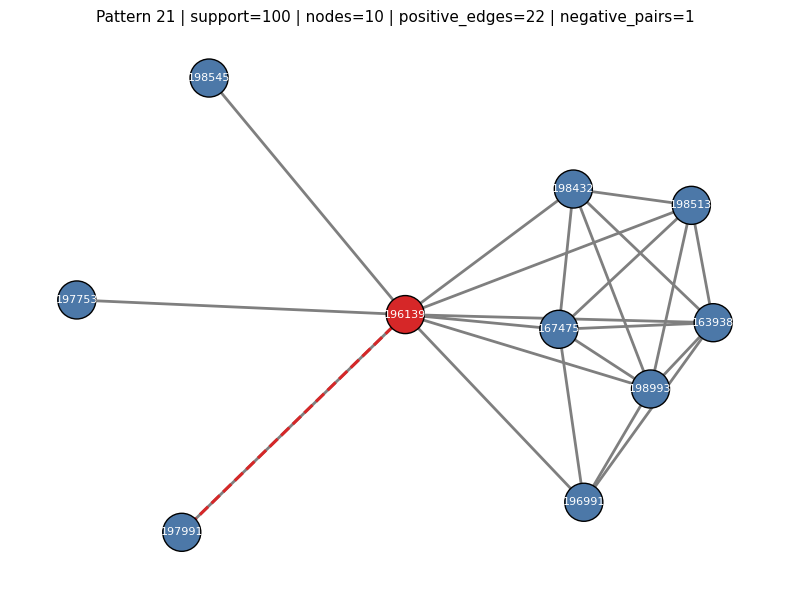

## Pattern 28

- support(match_count): 100

- center_orig_id: 154974

- orig_node_ids: [155648, 155649, 196618, 188426, 196620, 188429, 155990, 163030, 156187, 154974]

- positive_edges(index): [(155648, 155990), (155649, 155990), (154974, 155990), (154974, 156187), (154974, 163030), (155990, 188426), (155990, 188429), (155990, 196618), (155990, 196620)]

- negative_edge_pairs(index): [(154974, 156187)]

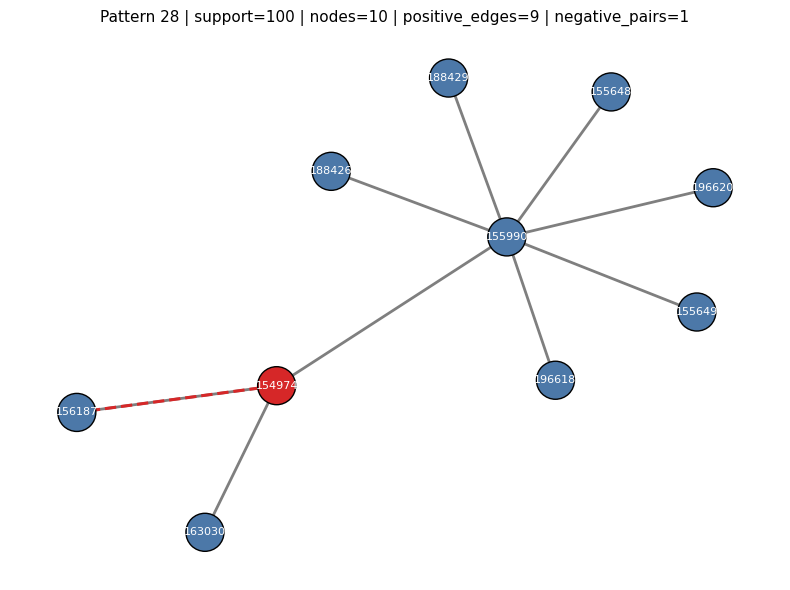

## Pattern 51

- support(match_count): 100

- center_orig_id: 192841

- orig_node_ids: [155810, 171300, 192841, 184908, 153326, 153488, 159157, 186714, 163995, 163423]

- positive_edges(index): [(153326, 153488), (153488, 186714), (155810, 159157), (159157, 163995), (153488, 171300), (171300, 192841), (153326, 192841), (153488, 192841), (159157, 192841), (163423, 192841), (184908, 192841), (186714, 192841)]

- negative_edge_pairs(index): [(159157, 163995), (159157, 192841)]

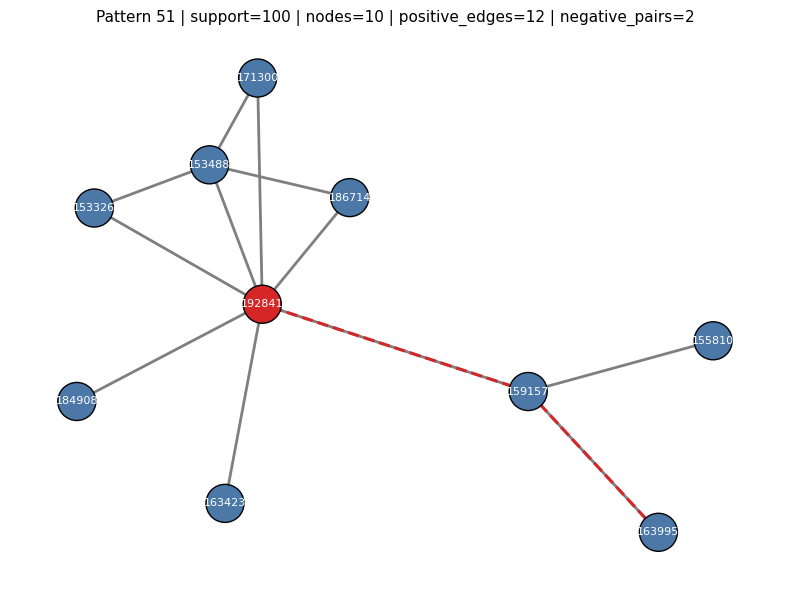

## Pattern 86

- support(match_count): 100

- center_orig_id: 158067

- orig_node_ids: [158755, 80995, 156713, 156458, 163980, 158446, 160334, 158067, 191897, 159195]

- positive_edges(index): [(80995, 158067), (156458, 158067), (156458, 160334), (156458, 156713), (156713, 158067), (156713, 159195), (156713, 160334), (158067, 159195), (158067, 191897), (158067, 158446), (158067, 158755), (158755, 163980), (158067, 160334)]

- negative_edge_pairs(index): [(158755, 163980)]

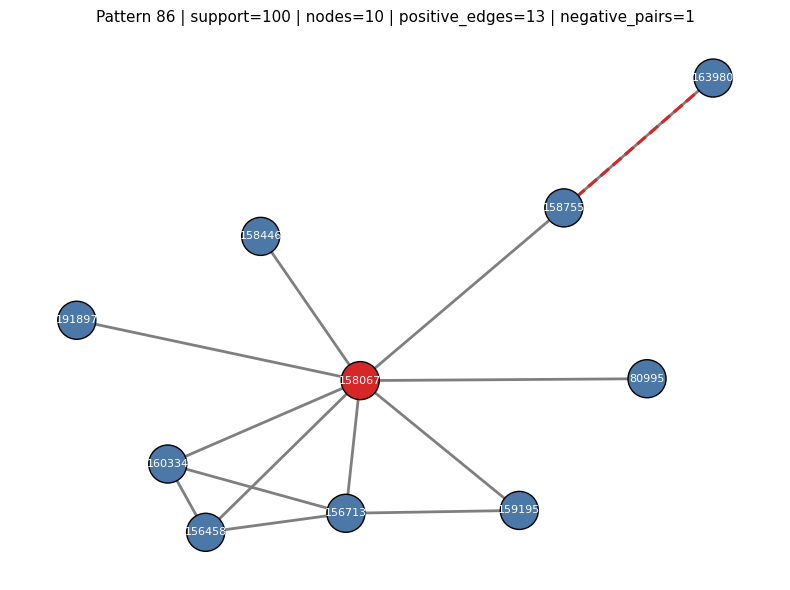

## Pattern 94

- support(match_count): 100

- center_orig_id: 181371

- orig_node_ids: [192865, 162818, 191333, 181371, 186389, 160219, 160921, 156186, 156187, 160894]

- positive_edges(index): [(156186, 156187), (160219, 160921), (156187, 162818), (160894, 162818), (162818, 181371), (162818, 191333), (156186, 181371), (156187, 181371), (160219, 181371), (160894, 181371), (160921, 181371), (181371, 186389), (156186, 191333), (156187, 191333), (181371, 191333), (181371, 192865), (191333, 192865)]

- negative_edge_pairs(index): [(156187, 162818)]

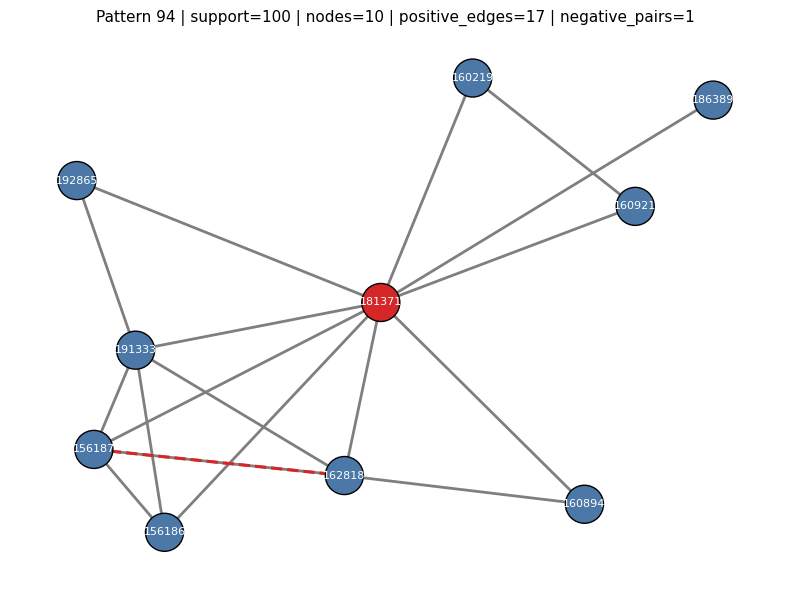

## Pattern 102

- support(match_count): 100

- center_orig_id: 77872

- orig_node_ids: [198181, 197607, 198443, 198861, 77872, 198621, 197269, 198393, 164028, 198493]

- positive_edges(index): [(77872, 164028), (77872, 197269), (77872, 198393), (77872, 198493), (77872, 198621), (77872, 197607), (197269, 197607), (197607, 198393), (197607, 198861), (77872, 198181), (197607, 198181), (198181, 198393), (198181, 198861), (77872, 198443), (77872, 198861), (198393, 198861)]

- negative_edge_pairs(index): [(77872, 164028), (77872, 198493), (77872, 198621)]

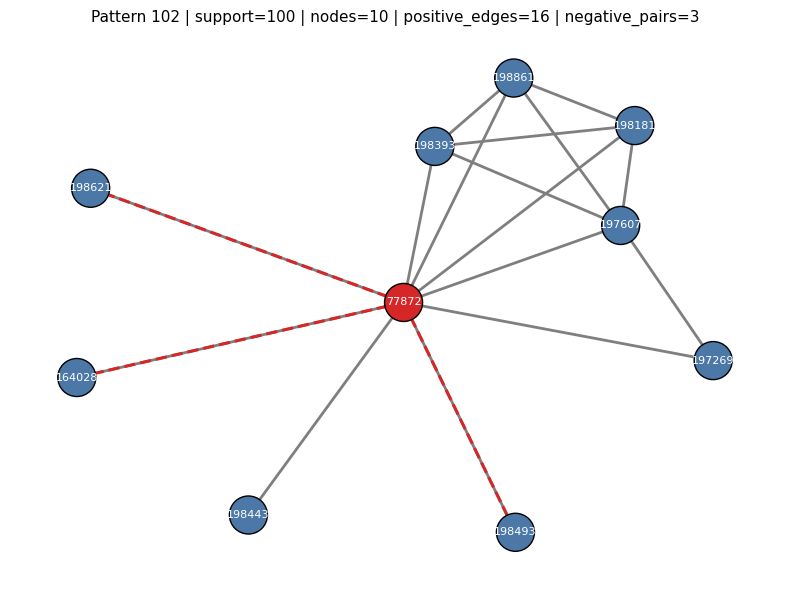

## Pattern 116

- support(match_count): 100

- center_orig_id: 188423

- orig_node_ids: [188423, 198443, 197740, 198925, 198894, 197269, 171897, 198043, 176797, 173886]

- positive_edges(index): [(171897, 188423), (173886, 188423), (176797, 188423), (188423, 197269), (188423, 197740), (188423, 198043), (188423, 198443), (188423, 198894), (188423, 198925), (176797, 197269), (176797, 198043), (171897, 198443), (198043, 198443), (198443, 198925), (176797, 198925), (197269, 198925), (198043, 198925)]

- negative_edge_pairs(index): [(171897, 188423), (171897, 198443)]

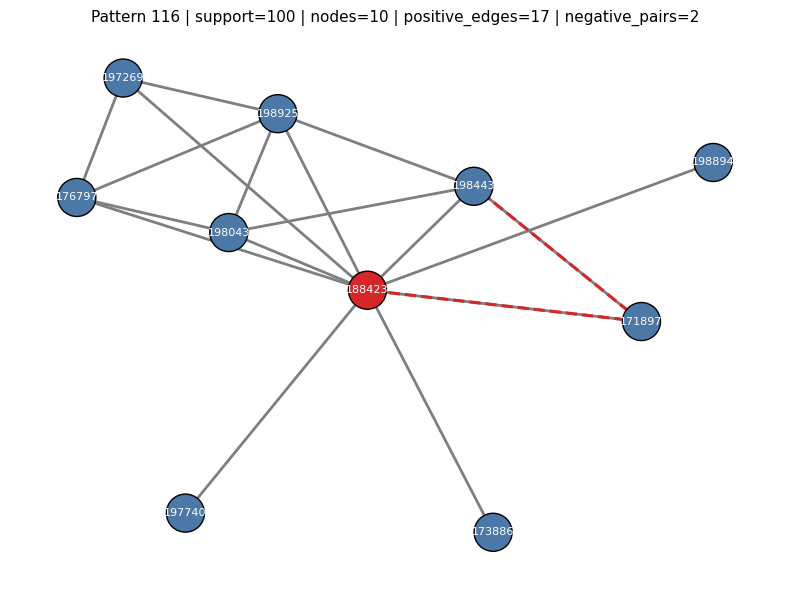

## Pattern 135

- support(match_count): 100

- center_orig_id: 191488

- orig_node_ids: [191488, 188416, 155650, 162534, 155654, 196616, 172041, 163859, 196628, 156446]

- positive_edges(index): [(155650, 156446), (155654, 156446), (156446, 163859), (156446, 172041), (156446, 188416), (156446, 191488), (162534, 191488), (156446, 196616), (156446, 196628)]

- negative_edge_pairs(index): [(156446, 196628)]

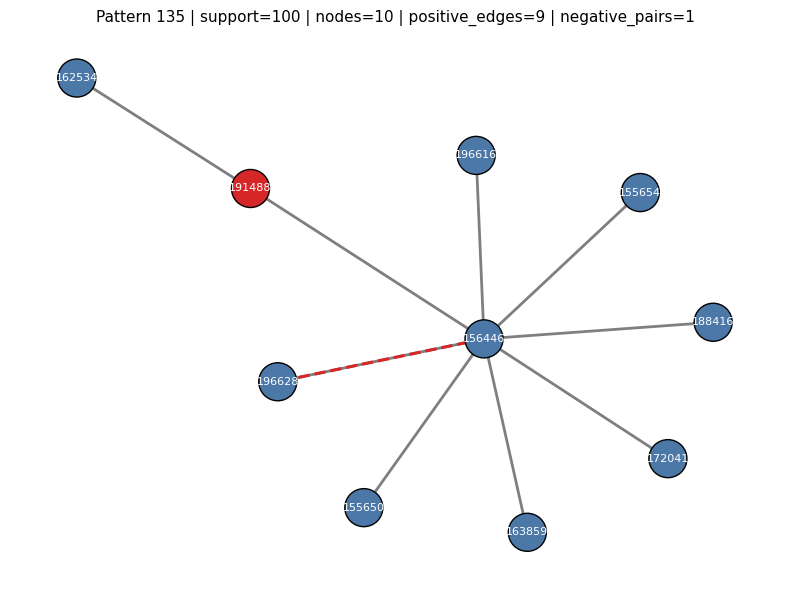

## Pattern 143

- support(match_count): 100

- center_orig_id: 190591

- orig_node_ids: [190884, 196713, 156009, 190413, 193395, 156472, 198782, 156187, 156574, 190591]

- positive_edges(index): [(156009, 190413), (156009, 190591), (156009, 193395), (156187, 190591), (156187, 156472), (156472, 190591), (156574, 190591), (190413, 190591), (190413, 193395), (156009, 190884), (190591, 190884), (190591, 193395), (190591, 196713), (190591, 198782)]

- negative_edge_pairs(index): [(156187, 190591)]

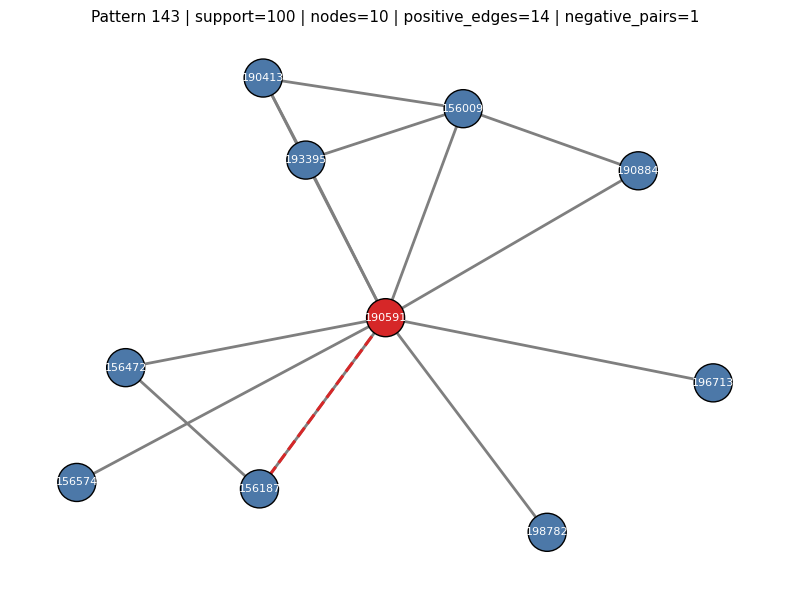

In [ ]:
displayed_patterns = []

for _, row in selected_rows.iterrows():
    graph_index = int(row['graph_index'])
    match_count = int(row['match_count'])

    result = json_by_graph[graph_index]
    graph, positive_edges, center_orig_id, orig_node_ids = build_pattern_graph(result)
    negative_pairs = find_negative_pairs(orig_node_ids, negative_edge_set)

    if negative_pairs:
        displayed_patterns.append({
            'graph_index': graph_index,
            'match_count': match_count,
            'negative_pairs': negative_pairs,
        })

        display(Markdown(f'## Pattern {graph_index}'))
        display(Markdown(f'- support(match_count): {match_count}'))
        display(Markdown(f"- center_orig_id: {center_orig_id}"))
        display(Markdown(f"- orig_node_ids: {orig_node_ids}"))
        display(Markdown(f'- positive_edges(index): {positive_edges}'))
        display(Markdown(f'- negative_edge_pairs(index): {negative_pairs if negative_pairs else []}'))

        draw_pattern(
            graph_index=graph_index,
            match_count=match_count,
            graph=graph,
            positive_edges=positive_edges,
            negative_pairs=negative_pairs,
            center_orig_id=center_orig_id,
            
        )

display(Markdown(f'**Actually visualized patterns with negative pairs: {len(displayed_patterns)}**'))


In [9]:
big_graph = load_or_build_big_graph(edge_csv=EDGE_CSV, node_csv=NODE_CSV, cache_path=BIG_GRAPH_CACHE)
edge_to_rows = load_or_build_interaction_lookup(INTERACTION_CSV, INTERACTION_LOOKUP_CACHE)

export_summaries = []
for item in displayed_patterns:
    graph_index = int(item['graph_index'])
    match_count = int(item['match_count'])
    negative_pairs = item['negative_pairs']
    result = json_by_graph[graph_index]
    pattern_graph, positive_edges, _, _ = build_pattern_graph(result)

    summary = export_pattern_hit_interactions(
        graph_index=graph_index,
        match_count=match_count,
        pattern_graph=pattern_graph,
        positive_edges=positive_edges,
        negative_pairs=negative_pairs,
        big_graph=big_graph,
        edge_to_rows=edge_to_rows,
        output_dir=EXPORT_DIR,
        max_matches=MAX_MATCHES_PER_PATTERN,
        timeout_seconds=TIMEOUT_SECONDS_PER_PATTERN,
    )
    export_summaries.append(summary)

summary_df = pd.DataFrame(export_summaries)
os.makedirs(EXPORT_DIR, exist_ok=True)
summary_csv = os.path.join(EXPORT_DIR, 'negative_pattern_export_summary.csv')
summary_df.to_csv(summary_csv, index=False)

display(Markdown(f'**Exported {len(summary_df)} csv files for the patterns actually visualized by the `if negative_pairs` block.**'))
display(Markdown(f'**Per-pattern limits: max_matches={MAX_MATCHES_PER_PATTERN}, timeout_seconds={TIMEOUT_SECONDS_PER_PATTERN}**'))
summary_df


**Exported 9 csv files for the patterns actually visualized by the `if negative_pairs` block.**

**Per-pattern limits: max_matches=200, timeout_seconds=60**

,graph_index,support_lower_bound,negative_pair_count,unique_hit_count_found,timed_out,elapsed_seconds,exported_interaction_rows,output_csv
0,21,100,1,200,False,0.684215,4400,/home/yyyy/codework/GARplus/enumeration-discov...
1,28,100,1,200,False,0.129943,1800,/home/yyyy/codework/GARplus/enumeration-discov...
2,51,100,2,200,False,5.282138,2400,/home/yyyy/codework/GARplus/enumeration-discov...
3,86,100,1,200,False,0.689109,2600,/home/yyyy/codework/GARplus/enumeration-discov...
4,94,100,1,200,False,2.285499,3400,/home/yyyy/codework/GARplus/enumeration-discov...
5,102,100,3,200,False,0.194807,3200,/home/yyyy/codework/GARplus/enumeration-discov...
6,116,100,2,200,False,0.759983,3400,/home/yyyy/codework/GARplus/enumeration-discov...
7,135,100,1,200,False,0.349494,1800,/home/yyyy/codework/GARplus/enumeration-discov...
8,143,100,1,200,False,20.429323,2800,/home/yyyy/codework/GARplus/enumeration-discov...
